# Filamentary Structure Validation

Walks a `base_dir` tree, finds every `SyntheticMap/` subfolder, matches each
synthetic-map FITS to its injected filaments via the shared `image_id` in
`filament_catalog.csv`, and measures flux recovery.

**Recovery criterion**: the summed flux inside the injected filament's Gaussian
footprint on the SyntheticMap must be within `FLUX_TOLERANCE` (default 10%) of
the `injected_flux` recorded in the catalog at injection time.

Results are plotted as boxplots grouped by filament property **and** by the
resolution scale extracted from the filename.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import pandas as pd
from astropy.io import fits
import cv2, warnings, os
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 1 · User Parameters

In [12]:
# ── Directory containing the catalog and all galaxy subfolders ────────────────
BASE_DIR       = r"C:\Users\jhoffm72\Documents\FilPHANGS\Validation_Data"

# Name of catalog CSV (must sit directly in BASE_DIR)
CATALOG_CSV    = 'filament_catalog.csv'

# Name of the subfolder inside each galaxy folder that holds SyntheticMap FITS
SYNMAP_SUBDIR  = 'SyntheticMap'

# Recovery tolerance: filament is "recovered" if
#   |recovered_flux - injected_flux| / injected_flux  <=  FLUX_TOLERANCE
FLUX_TOLERANCE = 0.25   # 10 %

# Visual style
MATCHED_COL = '#1a9e6e'
MISSED_COL  = '#d94f3d'
ALPHA       = 0.72

print('Parameters set.')

Parameters set.


## 2 · Helpers

In [13]:
# ── Scale extractor ───────────────────────────────────────────────────────────
# Handles CDD-style 'CDDss0256pc' (strips leading zeros → '256pc')
# and legacy plain '256pc' style.
import re as _re
def get_scale(fits_file):
    m = _re.search(r'CDDss(\d+)pc', fits_file)
    if m:
        return str(int(m.group(1))) + 'pc'
    legacy = [
        '1024pc','512pc','256pc','128pc','64pc','32pc','16pc',
        '8pc','4pc','2pc','1pc','.5pc','.25pc','.125pc','.0625pc','.03125pc'
    ]
    for scale in legacy:
        if scale in fits_file:
            return scale
    print(f"  WARNING: scale not recognised in '{fits_file}'")
    return 'unknown'

# ── Parse semicolon-separated path columns ────────────────────────────────────
def parse_path(row):
    r = np.array([float(v) for v in str(row['path_r']).split(';')])
    c = np.array([float(v) for v in str(row['path_c']).split(';')])
    return r, c

# ── Vectorised footprint mask ─────────────────────────────────────────────────
def get_footprint(path_r, path_c, width, img_rows, img_cols):
    hw      = int(np.ceil(4 * width))
    pr      = np.round(path_r).astype(int)
    pc      = np.round(path_c).astype(int)
    offsets = np.arange(-hw, hw + 1)
    dr, dc  = np.meshgrid(offsets, offsets, indexing='ij')
    dr      = dr.ravel(); dc = dc.ravel()
    all_r   = (pr[:, None] + dr[None, :]).ravel()
    all_c   = (pc[:, None] + dc[None, :]).ravel()
    valid   = (all_r >= 0) & (all_r < img_rows) & (all_c >= 0) & (all_c < img_cols)
    fp      = np.zeros((img_rows, img_cols), dtype=bool)
    fp[all_r[valid], all_c[valid]] = True
    return fp

# ── Load first 2-D HDU from a FITS file ───────────────────────────────────────
def load_fits_data(path):
    hdul = fits.open(path)
    data = None
    for hdu in hdul:
        if hdu.data is not None and hdu.data.ndim >= 2:
            data = np.squeeze(hdu.data).astype(np.float64)
            break
    hdul.close()
    if data is None:
        raise ValueError(f'No 2-D HDU found in {path}')
    return data

print('Helpers defined.')

Helpers defined.


## 3 · Discover Files & Match to Catalog

In [14]:
# ── Load catalog ──────────────────────────────────────────────────────────────
catalog_path = os.path.join(BASE_DIR, CATALOG_CSV)

# Diagnose BASE_DIR before anything else
if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(
        f"BASE_DIR not found: {BASE_DIR}\n"
        "Update the BASE_DIR variable in Cell 1 to point to your Validation_Data folder."
    )

if not os.path.exists(catalog_path):
    raise FileNotFoundError(
        f"Catalog CSV not found at: {catalog_path}\n"
        f"Files present in BASE_DIR: {os.listdir(BASE_DIR)}"
    )

catalog_df   = pd.read_csv(catalog_path)

# Normalise image_id to uppercase for consistent matching
catalog_df['image_id'] = catalog_df['image_id'].astype(str).str.upper()

print(f'Catalog loaded: {len(catalog_df)} filament rows, '
      f"{catalog_df['image_id'].nunique()} unique image IDs")

# ── Walk BASE_DIR looking for SyntheticMap subfolders ─────────────────────────
# Expected layout:
#   BASE_DIR/
#     <galaxy_folder>/
#       SyntheticMap/
#         <base>_modified_<IMAGE_ID>.fits
#     filament_catalog.csv

synmap_files = []   # list of (image_id, scale, fits_path)

for root, dirs, files in os.walk(BASE_DIR):
    if os.path.basename(root) == SYNMAP_SUBDIR:
        for fname in sorted(files):
            # Match .fits, .fit, and double-extension like .fits_SyntheticMapApprox.fits
            fname_lower = fname.lower()
            if not (fname_lower.endswith('.fits') or fname_lower.endswith('.fit')
                    or '.fits_' in fname_lower):
                continue
            # Accept .fits, .fit, and double-extension like .fits_SyntheticMapApprox.fits
            # Image ID is the 8-character hex token embedded in the filename.
            # e.g. ngc1433_F770W_..._EF7D6A87_CDDss0256pc.fits_SyntheticMapApprox.fits
            hex_match = _re.search(r'_([0-9A-Fa-f]{8})_', fname)
            if not hex_match:
                # fallback: legacy _modified_<ID> pattern
                parts = fname.split('_modified_')
                if len(parts) >= 2:
                    image_id = parts[-1].split('.')[0].upper()
                else:
                    print(f'  SKIP (cannot parse image_id): {fname}')
                    continue
            else:
                image_id = hex_match.group(1).upper()
            scale    = get_scale(fname)
            synmap_files.append((image_id, scale, os.path.join(root, fname)))

print(f'Found {len(synmap_files)} SyntheticMap FITS files.')

# ── Check if any SyntheticMap files were found ────────────────────────────────────
if len(synmap_files) == 0:
    print('No validation data found — SyntheticMap folder is empty or missing. Skipping analysis.')
else:
    catalog_ids = set(catalog_df['image_id'].unique())
    found_ids   = set(x[0] for x in synmap_files)
    missing_ids = catalog_ids - found_ids
    extra_ids   = found_ids   - catalog_ids
    if missing_ids:
        print(f'  WARNING: {len(missing_ids)} catalog image_id(s) have no SyntheticMap: {missing_ids}')
    if extra_ids:
        print(f'  WARNING: {len(extra_ids)} SyntheticMap(s) have no catalog rows: {extra_ids}')
    if not missing_ids and not extra_ids:
        print('  All image IDs match between catalog and SyntheticMap files.')

Catalog loaded: 1335 filament rows, 20 unique image IDs
Found 5 SyntheticMap FITS files.


## 4 · Flux Recovery Loop

In [15]:
if len(synmap_files) == 0:
    print('No validation data found — skipping flux recovery.')
    results_df = __import__('pandas').DataFrame()
else:
    all_results = []   # one dict per filament
    
    for image_id, scale, synmap_path in synmap_files:
        rows = catalog_df[catalog_df['image_id'] == image_id]
        if len(rows) == 0:
            print(f'  [{image_id}] No catalog rows — skipping.')
            continue
    
        print(f'\n[{image_id}]  scale={scale}  file={os.path.basename(synmap_path)}')
        print(f'  {len(rows)} filaments to validate')
    
        try:
            syn_data = load_fits_data(synmap_path)
        except Exception as e:
            print(f'  ERROR loading file: {e} — skipping.')
            continue
    
        img_rows, img_cols = syn_data.shape
    
        for _, row in rows.iterrows():
            path_r, path_c = parse_path(row)
            width          = float(row['width'])
            injected_flux  = float(row['injected_flux'])
    
            # Build the same footprint used at injection time and sum SyntheticMap pixels
            fp = get_footprint(path_r, path_c, width, img_rows, img_cols)
            recovered_flux = float(np.nansum(syn_data[fp]))
    
            flux_error = (abs(recovered_flux - injected_flux) / injected_flux
                          if injected_flux > 0 else np.nan)
            recovered  = (flux_error <= FLUX_TOLERANCE) if not np.isnan(flux_error) else False
    
            all_results.append({
                'image_id':       image_id,
                'scale':          scale,
                'label':          int(row['label']),
                'length':         int(row['length']),
                'width':          width,
                'tortuosity':     float(row['tortuosity']),
                'profile':        str(row['profile']),
                'i_lo':           float(row['i_lo']),
                'i_hi':           float(row['i_hi']),
                'injected_flux':  round(injected_flux, 4),
                'recovered_flux': round(recovered_flux, 4),
                'flux_ratio':     round(recovered_flux / injected_flux, 4) if injected_flux > 0 else np.nan,
                'flux_error':     round(flux_error, 4) if not np.isnan(flux_error) else np.nan,
                'recovered':      recovered,
                'path_r':         str(row['path_r']),
                'path_c':         str(row['path_c']),
            })
    
    results_df = pd.DataFrame(all_results)
    
    # ── Guard: stop here with a clear message if nothing was processed ────────────
    if len(results_df) == 0:
        raise RuntimeError(
            "results_df is empty — no filaments were processed.\n"
            "Likely causes:\n"
            "  1. synmap_files is empty (check Cell 3 diagnostics).\n"
            "  2. FITS filenames do not contain '_modified_<IMAGE_ID>' where IMAGE_ID "
            "matches a value in the catalog's 'image_id' column.\n"
            "  3. All FITS files failed to load (check for errors printed above).\n"
            "Fix the issue in Cell 3 / Cell 1 before re-running."
        )
    
    recovered_df = results_df[results_df['recovered']]
    missed_df    = results_df[~results_df['recovered']]
    
    n_total = len(results_df)
    n_rec   = int(results_df['recovered'].sum())
    print(f'\nOverall: {n_rec} / {n_total} filaments recovered ({100*n_rec/n_total:.1f}%)')
    print(results_df[['image_id','scale','label','length','width',
                       'injected_flux','recovered_flux','flux_error','recovered']].to_string(index=False))



[26D1C166]  scale=16pc  file=ngc0628_F770W_JWST_Emission_starsub_26D1C166_CDDss0016pc.fits_SyntheticMap_NotGrouped.fits
  75 filaments to validate

[26D1C166]  scale=32pc  file=ngc0628_F770W_JWST_Emission_starsub_26D1C166_CDDss0032pc.fits_SyntheticMap_Grouped.fits
  75 filaments to validate

[26D1C166]  scale=64pc  file=ngc0628_F770W_JWST_Emission_starsub_26D1C166_CDDss0064pc.fits_SyntheticMap_Grouped.fits
  75 filaments to validate

[26D1C166]  scale=128pc  file=ngc0628_F770W_JWST_Emission_starsub_26D1C166_CDDss0128pc.fits_SyntheticMap_Grouped.fits
  75 filaments to validate

[26D1C166]  scale=256pc  file=ngc0628_F770W_JWST_Emission_starsub_26D1C166_CDDss0256pc.fits_SyntheticMap_Grouped.fits
  75 filaments to validate

Overall: 37 / 375 filaments recovered (9.9%)
image_id scale  label  length  width  injected_flux  recovered_flux  flux_error  recovered
26D1C166  16pc      1     128  10.01      3557.9606       2814.1361      0.2091       True
26D1C166  16pc      2      15   5.00      

## 5 · Summary Tables & Statistical Tests

In [16]:
if results_df.empty:
    print('No validation data found — skipping summary tables and statistical tests.')
else:
    def row_stats(series):
        s = series.dropna()
        if len(s) == 0:
            return {k: '—' for k in ['N','Mean','Median','Std','Min','Max']}
        return {'N':len(s),'Mean':f'{s.mean():.3f}','Median':f'{s.median():.3f}',
                'Std':f'{s.std():.3f}','Min':f'{s.min():.3f}','Max':f'{s.max():.3f}'}
    
    props = [
        ('length',     'Length (px)'),
        ('width',      'Width (px)'),
        ('tortuosity', 'Tortuosity'),
        ('i_lo',       'Intensity lo'),
        ('i_hi',       'Intensity hi'),
        ('flux_error', 'Flux error'),
        ('flux_ratio', 'Flux ratio'),
    ]
    col_w = [16,8,8,8,8,8,8]
    hdr   = ['Property','N','Mean','Median','Std','Min','Max']
    sep   = '+' + '+'.join('-'*(w+2) for w in col_w) + '+'
    fmt   = '| ' + ' | '.join(f'{{:<{w}}}' for w in col_w) + ' |'
    n_missed = n_total - n_rec
    print(f'  VALIDATION SUMMARY — flux tolerance {FLUX_TOLERANCE*100:.0f}%')
    print(f'  Total: {n_total}   Recovered: {n_rec} ({100*n_rec/n_total:.1f}%)   '
          f'Missed: {n_missed} ({100*n_missed/n_total:.1f}%)')
    print()
    for group_label, df_sub in [('RECOVERED', recovered_df), ('MISSED', missed_df)]:
        print(f'  ── {group_label} ({len(df_sub)} filaments)')
        print('  ' + sep)
        print('  ' + fmt.format(*hdr))
        print('  ' + sep)
        for col, label in props:
            s = row_stats(df_sub[col])
            print('  ' + fmt.format(label, s['N'], s['Mean'], s['Median'], s['Std'], s['Min'], s['Max']))
        print('  ' + sep)
        print()
    
    test_props = [
        ('length',    'longer',            'shorter'),
        ('width',     'wider',             'narrower'),
        ('tortuosity','higher tortuosity', 'lower tortuosity'),
        ('i_lo',      'higher i_lo',       'lower i_lo'),
        ('i_hi',      'higher i_hi',       'lower i_hi'),
    ]
    pw=[16,10,8,10,30]
    phdr=['Property','Stat (U)','p-value','Sig?','Direction']
    psep='+'+'+'.join('-'*(w+2) for w in pw)+'+'
    pfmt='| '+' | '.join(f'{{:<{w}}}' for w in pw)+' |'
    print('  ── Statistical tests (Mann-Whitney U, two-sided)')
    print('  '+psep); print('  '+pfmt.format(*phdr)); print('  '+psep)
    conclusions = []
    for col, hi_word, lo_word in test_props:
        a = recovered_df[col].dropna().values
        b = missed_df[col].dropna().values
        if len(a) < 2 or len(b) < 2:
            print('  '+pfmt.format(col,'—','—','—','insufficient data'))
            continue
        stat, p = scipy_stats.mannwhitneyu(a, b, alternative='two-sided')
        sig  = 'YES *' if p < 0.05 else 'no'
        word = hi_word if a.mean() > b.mean() else lo_word
        pstr = f'{p:.4f}' if p >= 0.0001 else f'{p:.2e}'
        print('  '+pfmt.format(col, f'{stat:.1f}', pstr, sig, f'recovered {word}'))
        if p < 0.05:
            level = 'p<0.001' if p<0.001 else ('p<0.01' if p<0.01 else 'p<0.05')
            conclusions.append(f'Filaments with {word} more likely recovered ({level}, U={stat:.0f}).')
    print('  '+psep)
    print()
    if conclusions:
        print('  ── CONCLUSIONS')
        for i, c in enumerate(conclusions, 1): print(f'  {i}. {c}')
    else:
        print('  ── CONCLUSIONS: No statistically significant differences found.')


  VALIDATION SUMMARY — flux tolerance 25%
  Total: 375   Recovered: 37 (9.9%)   Missed: 338 (90.1%)

  ── RECOVERED (37 filaments)
  +------------------+----------+----------+----------+----------+----------+----------+
  | Property         | N        | Mean     | Median   | Std      | Min      | Max      |
  +------------------+----------+----------+----------+----------+----------+----------+
  | Length (px)      | 37       | 37.405   | 24.000   | 30.536   | 15.000   | 128.000  |
  | Width (px)       | 37       | 9.215    | 8.650    | 3.273    | 5.000    | 17.010   |
  | Tortuosity       | 37       | 1.338    | 1.151    | 0.497    | 1.003    | 3.075    |
  | Intensity lo     | 37       | 0.734    | 0.328    | 0.958    | 0.050    | 3.585    |
  | Intensity hi     | 37       | 2.826    | 2.468    | 1.522    | 0.257    | 5.000    |
  | Flux error       | 37       | 0.118    | 0.110    | 0.068    | 0.009    | 0.247    |
  | Flux ratio       | 37       | 0.951    | 0.923    | 0.128    | 0

## 6 · Boxplots Grouped by Filament Property & Scale

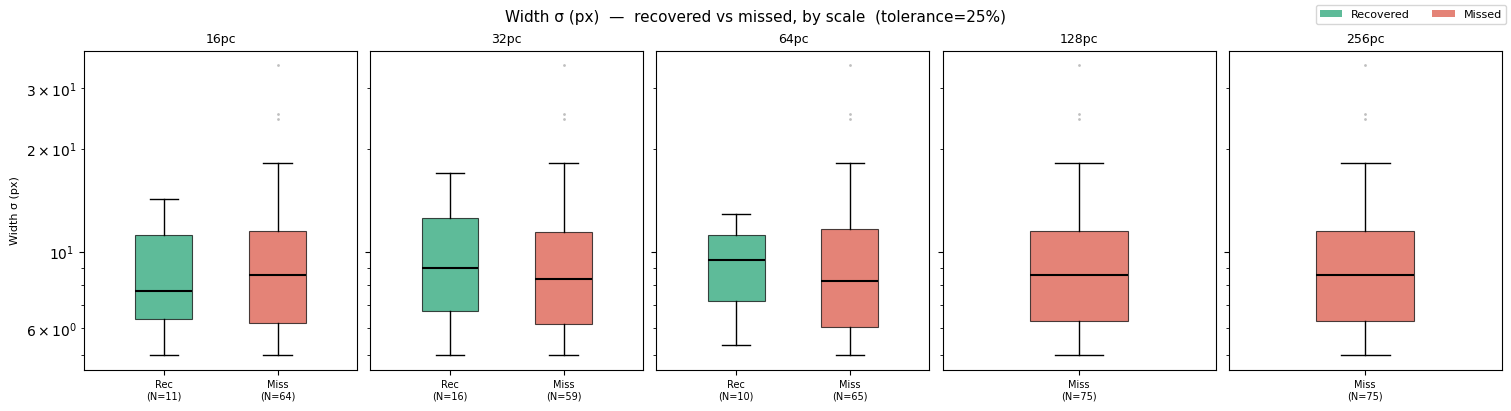

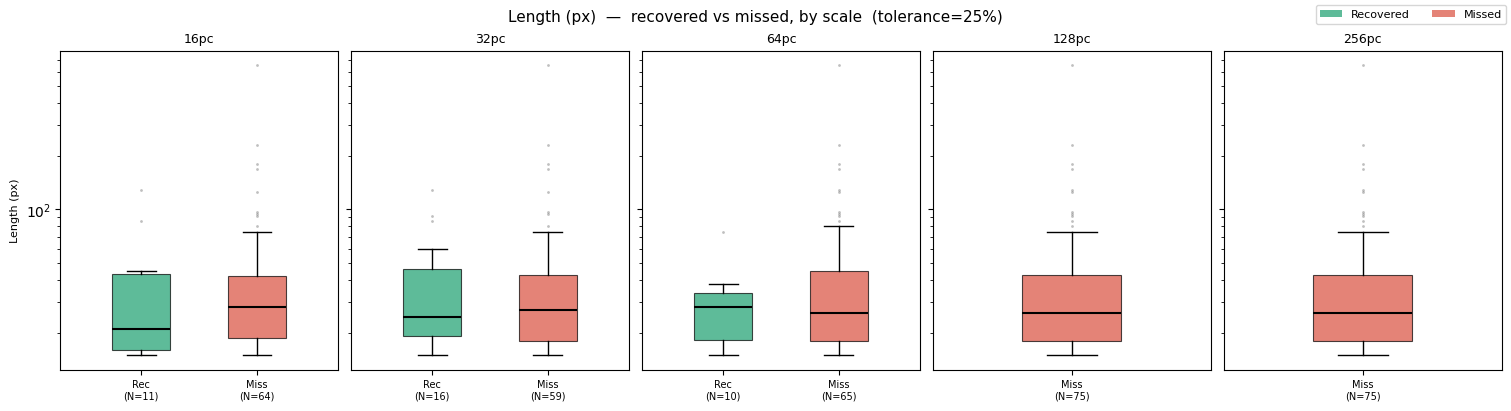

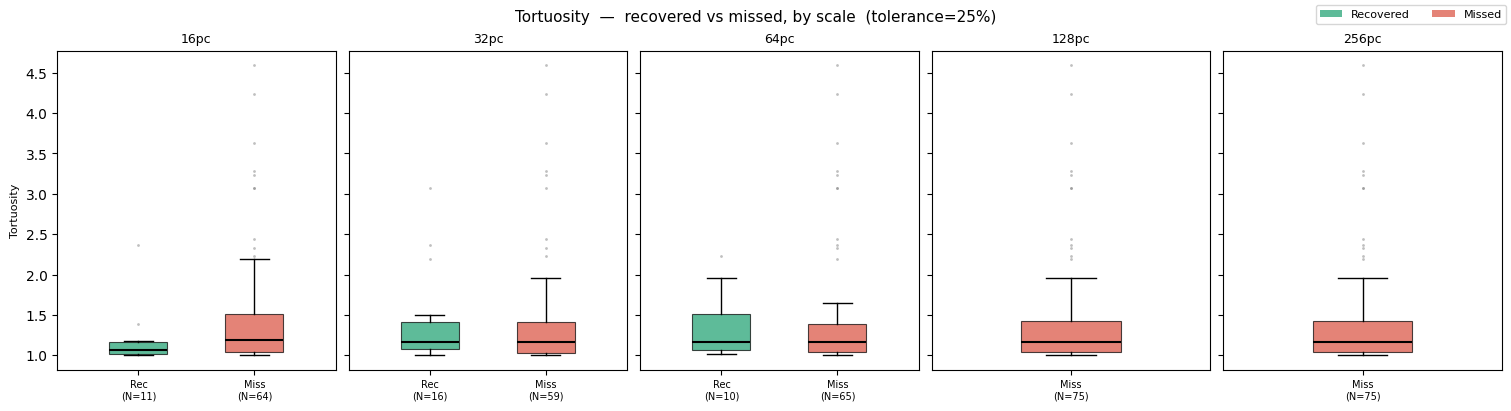

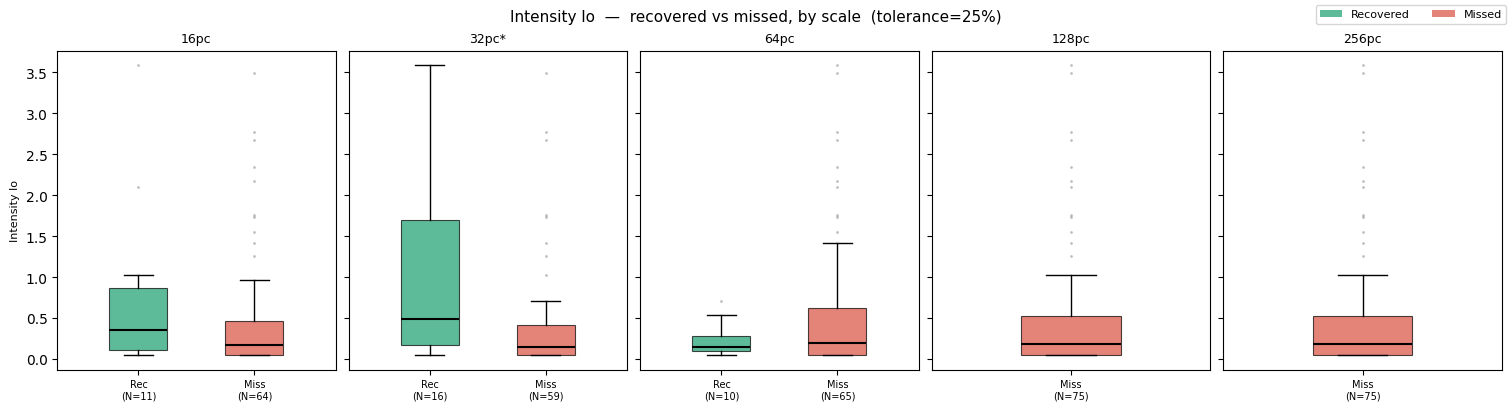

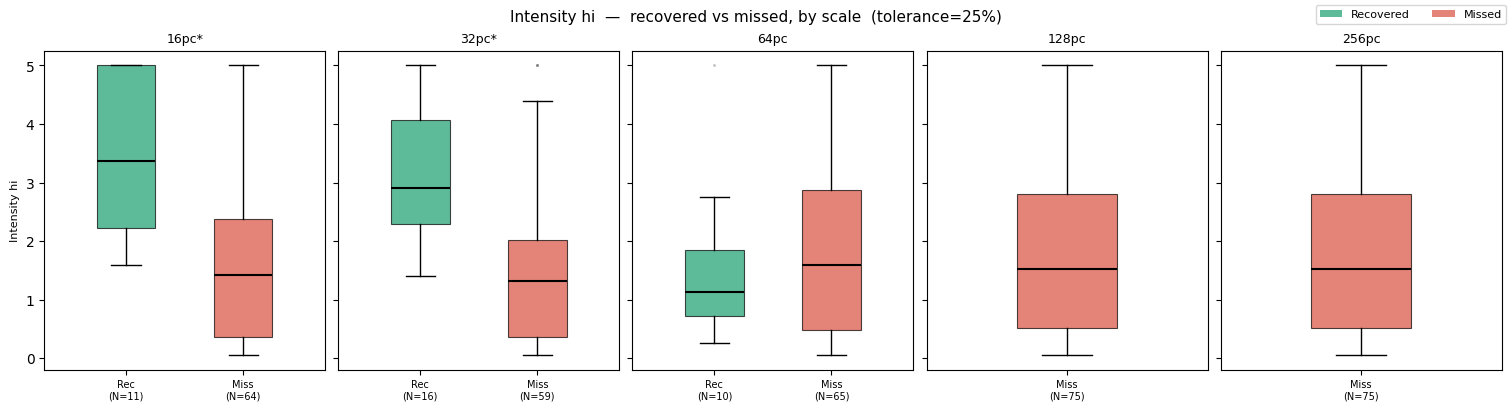

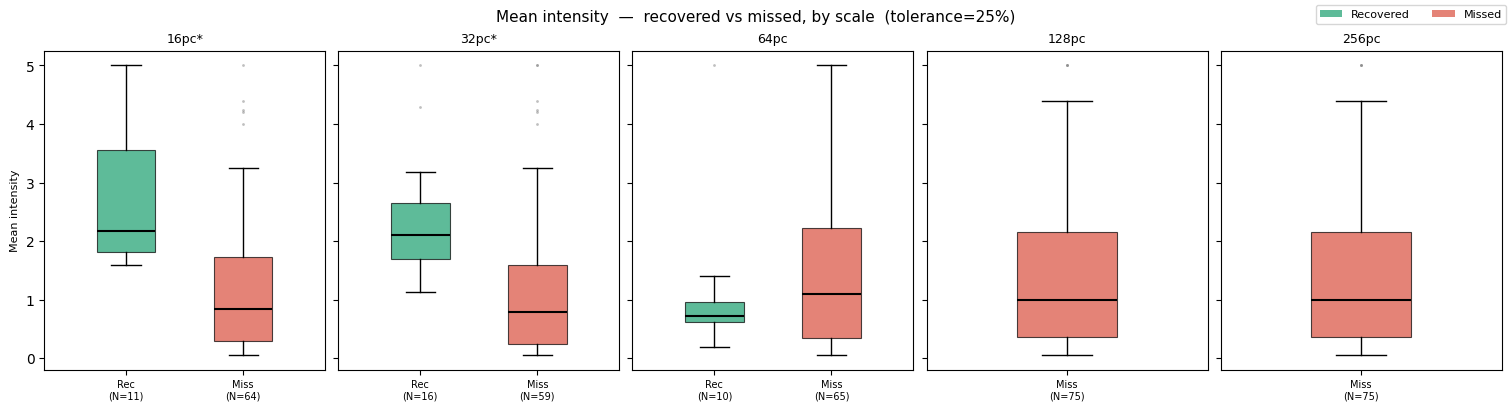

In [ ]:
if results_df.empty:
    print('No validation data found — skipping boxplots.')
else:
    def ptest(a, b):
        if len(a) < 2 or len(b) < 2: return np.nan, np.nan
        return scipy_stats.mannwhitneyu(a, b, alternative='two-sided')

    def scale_sort_key(s):
        m = _re.search(r'(\d+)', s)
        return int(m.group(1)) if m else 0

    def compute_mean_intensity(row):
        lo, hi, n, profile = row['i_lo'], row['i_hi'], int(row['length']) + 1, row['profile']
        t = np.linspace(0.0, 1.0, n)
        if   profile == 'constant': vals = np.full(n, hi)
        elif profile == 'linear':   vals = lo + (hi - lo) * t
        elif profile == 'sin':      vals = lo + (hi - lo) * 0.5 * (1 + np.sin(2 * np.pi * t))
        elif profile == 'sin2':     vals = lo + (hi - lo) * 0.5 * (1 + np.sin(4 * np.pi * t))
        elif profile == 'gaussian': vals = lo + (hi - lo) * np.exp(-0.5 * ((t - 0.5) / 0.2) ** 2)
        else:                       vals = np.full(n, hi)
        return float(vals.mean())

    if 'mean_intensity' not in results_df.columns:
        results_df['mean_intensity'] = results_df.apply(compute_mean_intensity, axis=1)

    scales_ordered = sorted(results_df['scale'].unique(), key=scale_sort_key)
    n_scales = len(scales_ordered)

    props = [
        ('width',           'Width σ (px)',      True),
        ('length',          'Length (px)',        True),
        ('tortuosity',      'Tortuosity',         False),
        ('i_lo',            'Intensity lo',       False),
        ('i_hi',            'Intensity hi',       False),
        ('mean_intensity',  'Mean intensity',     False),
    ]

    for col, ylabel, log_y in props:
        fig, axes = plt.subplots(1, n_scales, figsize=(max(3 * n_scales, 7), 4),
                                 sharey=True, constrained_layout=True)
        if n_scales == 1:
            axes = [axes]

        for i, (ax, scale) in enumerate(zip(axes, scales_ordered)):
            sub       = results_df[results_df['scale'] == scale]
            rec_vals  = sub[ sub['recovered']][col].dropna().values
            miss_vals = sub[~sub['recovered']][col].dropna().values

            data_list, colors, tick_labels = [], [], []
            if len(rec_vals)  >= 2:
                data_list.append(rec_vals);  colors.append(MATCHED_COL)
                tick_labels.append(f'Rec\n(N={len(rec_vals)})')
            if len(miss_vals) >= 2:
                data_list.append(miss_vals); colors.append(MISSED_COL)
                tick_labels.append(f'Miss\n(N={len(miss_vals)})')

            if not data_list:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='grey')
                ax.set_title(scale, fontsize=9)
                continue

            positions = list(range(1, len(data_list) + 1))
            bp = ax.boxplot(data_list, positions=positions, widths=0.5,
                            patch_artist=True,
                            medianprops=dict(color='black', linewidth=1.5),
                            whiskerprops=dict(color='black', linewidth=1),
                            capprops=dict(color='black', linewidth=1),
                            flierprops=dict(marker='o', markersize=2,
                                            markerfacecolor='grey',
                                            markeredgecolor='none', alpha=0.5),
                            boxprops=dict(linewidth=0.8))
            for patch, c in zip(bp['boxes'], colors):
                patch.set_facecolor(c)
                patch.set_alpha(0.7)

            ax.set_xticks(positions)
            ax.set_xticklabels(tick_labels, fontsize=7)
            ax.set_xlim(0.3, len(data_list) + 0.7)
            if i == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if log_y:
                ax.set_yscale('log')

            _, p = ptest(rec_vals, miss_vals)
            sig = '*' if (not np.isnan(p) and p < 0.05) else ''
            ax.set_title(f'{scale}{sig}', fontsize=9)

        handles = [
            plt.Rectangle((0,0), 1, 1, facecolor=MATCHED_COL, alpha=0.7, label='Recovered'),
            plt.Rectangle((0,0), 1, 1, facecolor=MISSED_COL,  alpha=0.7, label='Missed'),
        ]
        fig.legend(handles=handles, loc='upper right', fontsize=8, ncol=2)
        fig.suptitle(
            f'{ylabel}  —  recovered vs missed, by scale  (tolerance={FLUX_TOLERANCE*100:.0f}%)',
            fontsize=11)
        plt.show()

## 7 · Per-Image Spatial Map

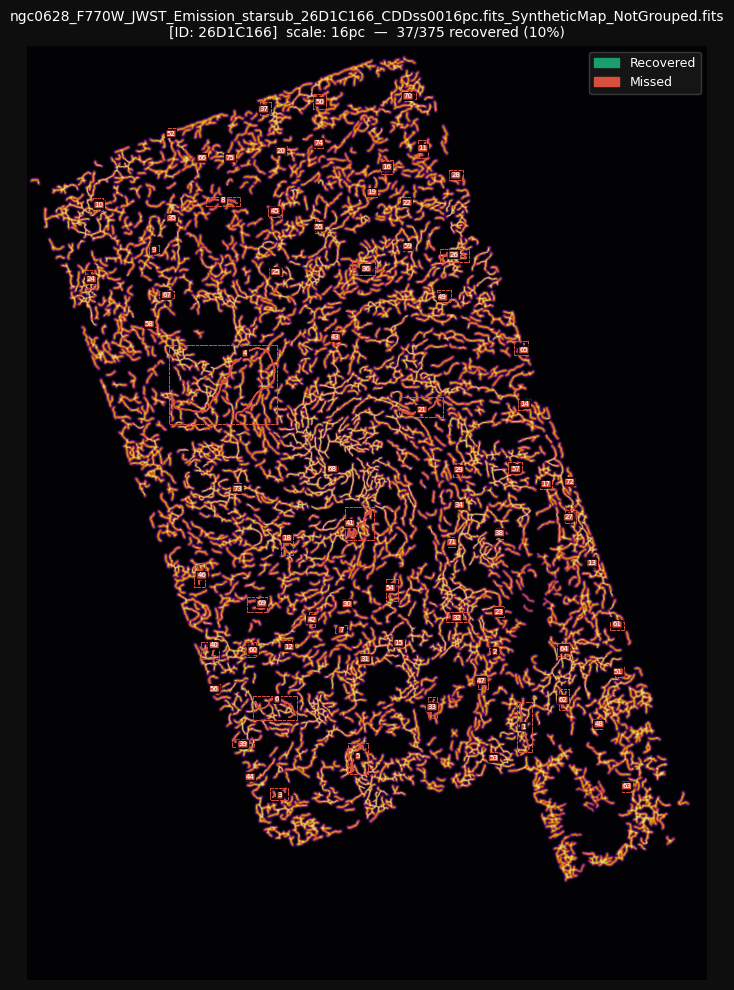

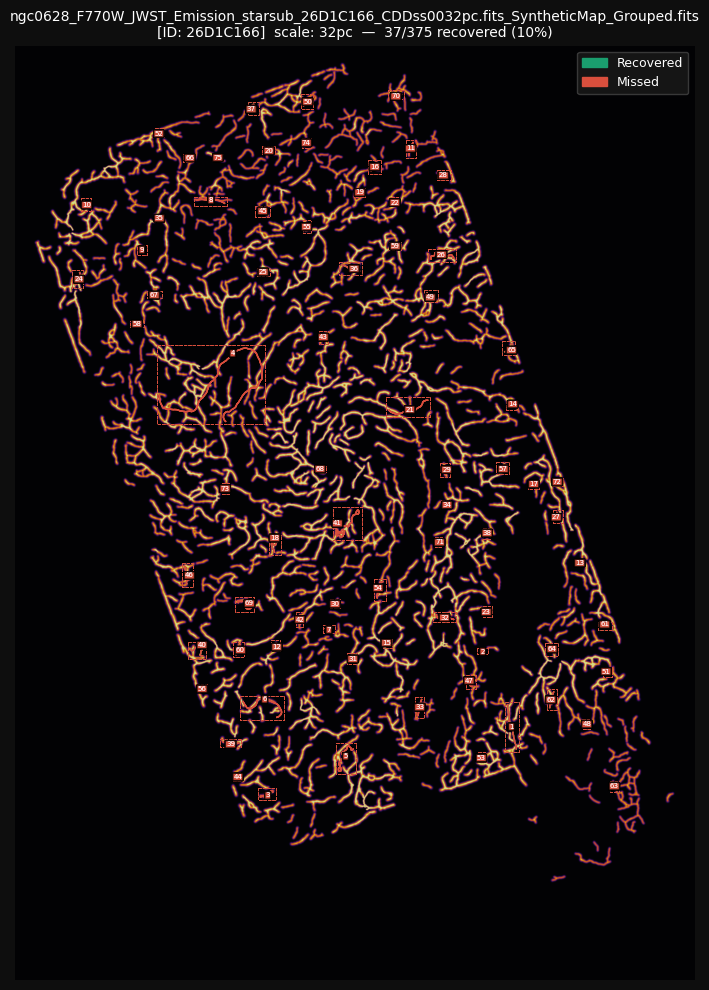

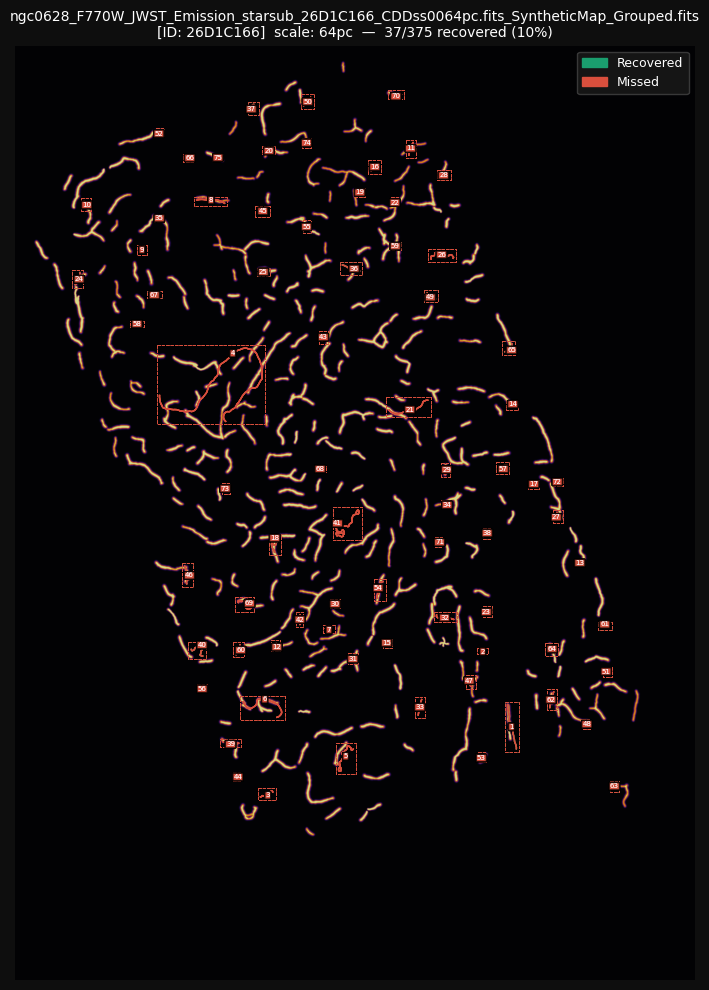

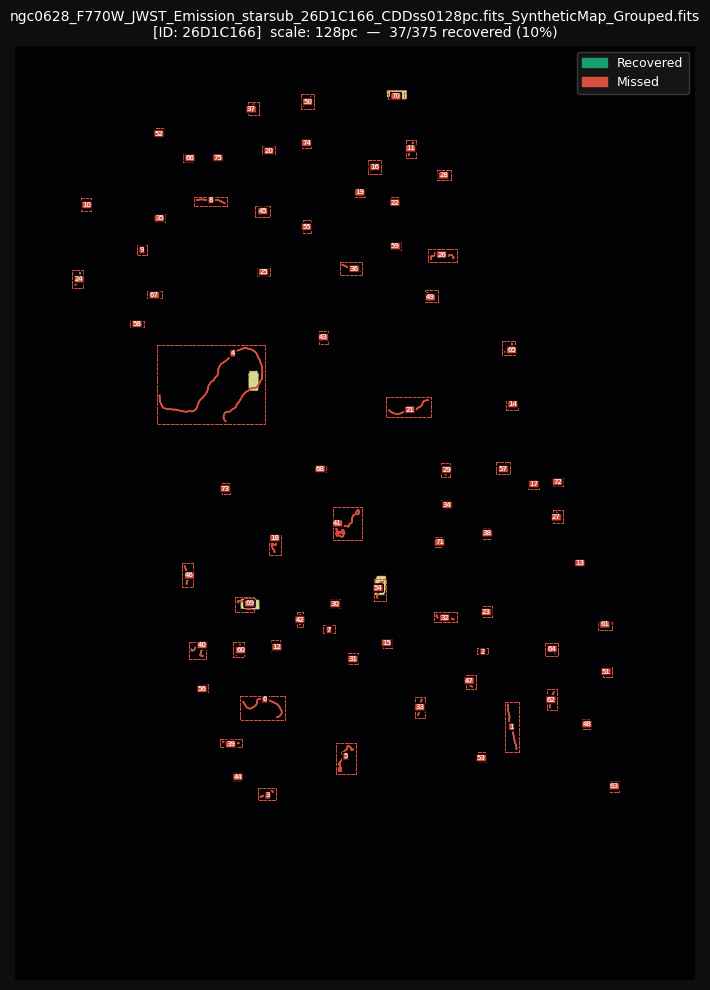

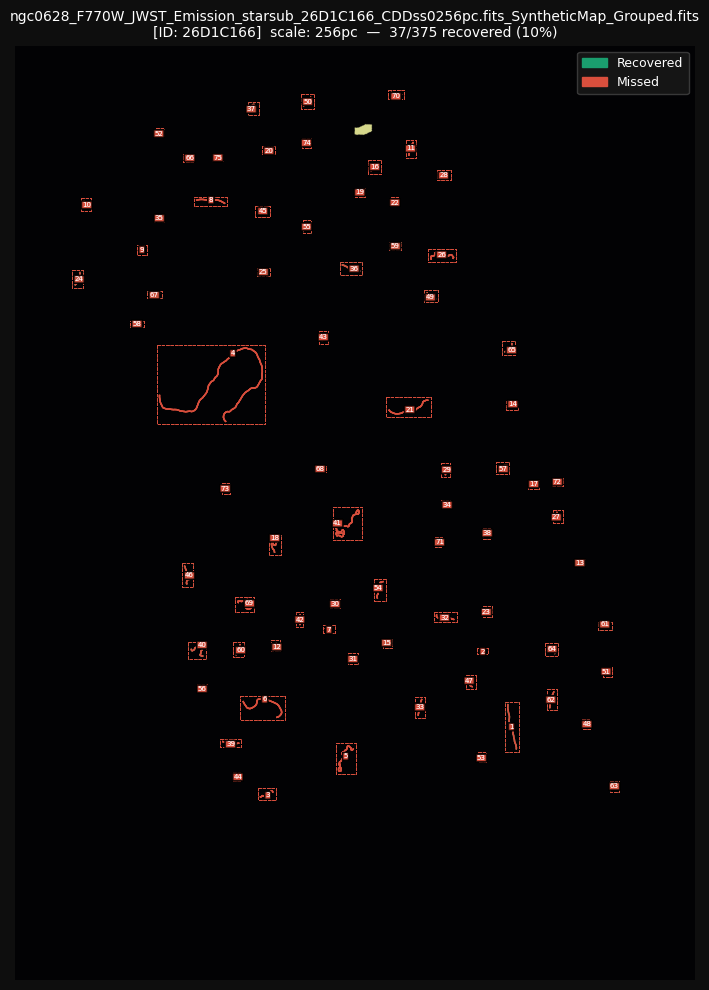

In [18]:
if results_df.empty:
    print('No validation data found — skipping spatial maps.')
else:
    for image_id, scale, synmap_path in synmap_files:
        rows = results_df[results_df['image_id'] == image_id]
        if len(rows) == 0:
            continue
        try:
            syn_data = load_fits_data(synmap_path)
        except Exception:
            continue
    
        lo_p, hi_p  = np.nanpercentile(syn_data[np.isfinite(syn_data)], [1, 99])
        display_syn = np.clip((np.nan_to_num(syn_data) - lo_p) / (hi_p - lo_p + 1e-30), 0, 1)
    
        n_rec_img = int(rows['recovered'].sum())
        n_tot_img = len(rows)
    
        fig, ax = plt.subplots(figsize=(10, 10))
        fig.patch.set_facecolor('#0e0e0e')
        ax.set_facecolor('black')
        ax.imshow(display_syn, origin='upper', cmap='inferno',
                  norm=mcolors.PowerNorm(gamma=0.5), alpha=0.85)
    
        for _, row in rows.iterrows():
            path_r, path_c = parse_path(row)
            col_ = MATCHED_COL if row['recovered'] else MISSED_COL
            ax.plot(path_c, path_r, color=col_, lw=1.0, alpha=0.85)
            pad = 8
            r_min, r_max = path_r.min()-pad, path_r.max()+pad
            c_min, c_max = path_c.min()-pad, path_c.max()+pad
            rect = mpatches.Rectangle(
                (c_min, r_min), c_max-c_min, r_max-r_min,
                linewidth=0.6, edgecolor=col_, facecolor='none', linestyle='--'
            )
            ax.add_patch(rect)
            mid = len(path_r) // 2
            ax.text(path_c[mid], path_r[mid], str(int(row['label'])),
                    color='white', fontsize=5, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.1', fc=col_, alpha=0.65))
    
        rec_patch  = mpatches.Patch(color=MATCHED_COL, label='Recovered')
        miss_patch = mpatches.Patch(color=MISSED_COL,  label='Missed')
        ax.legend(handles=[rec_patch, miss_patch], loc='upper right', fontsize=9,
                  facecolor='#1a1a1a', labelcolor='white', edgecolor='#444')
        ax.set_title(
            f'{os.path.basename(synmap_path)}\n'
            f'[ID: {image_id}]  scale: {scale}  —  '
            f'{n_rec_img}/{n_tot_img} recovered ({100*n_rec_img/n_tot_img:.0f}%)',
            color='white', fontsize=10
        )
        ax.axis('off')
        plt.tight_layout()
        plt.show()
